In [1]:
getwd()

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/04_RNA_DNA/src"

In [2]:
library(Seurat)
library(dplyr)

Warning message:
“package ‘Seurat’ was built under R version 4.3.3”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.3.3”
Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.3.2”

Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
data <- read.csv("../03-ExpressionCorrelated_loops_with_hyperDHMR/example_Vwc2/data_55kb_bin_by_cell_for_Vwc2.csv",row.names = 1)

In [4]:
head(data);dim(data)

,unique_id,hmC_SampleID,hmC_QC,mC_SampleID,mC_QC,RNA_SampleID,RNA_QC,total_QC,class_label,subclass_label,three_class,Region,Brain_Region,Neuron_non_neuron,X5hmCG_chr11_10805000_10860000,X5mCG_chr11_10805000_10860000,fillNA_5hmCG_chr11_10805000_10860000,fillNA_5mCG_chr11_10805000_10860000,fillNA_true5mCG_chr11_10805000_10860000,ENSMUSG00000050830.17
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1152,P49_Male_LeftCortex_plate1.AACCAGAG,P49_Male_LeftCortex_TSO_joint5hmC_plate1.AACCAGAG,1,P49_Male_LeftCortex_TSO_joint5mC_plate1.AACCAGAG,1,P49_Male_LeftCortex_TSO_RNA_plate1.AACCAGAG,1,1,IT-ET Glut,L4/5 IT CTX Glut,Exc,LeftCortex,Cortex,Neuron,0.0000000,NA,0.0000000,0.8721771,0.8721771,0.0000000
1153,P49_Male_LeftCortex_plate1.AAGACACC,P49_Male_LeftCortex_TSO_joint5hmC_plate1.AAGACACC,1,P49_Male_LeftCortex_TSO_joint5mC_plate1.AAGACACC,1,P49_Male_LeftCortex_TSO_RNA_plate1.AAGACACC,1,1,IT-ET Glut,CLA-EPd-CTX Car3 Glut,Exc,LeftCortex,Cortex,Neuron,NA,1.0000000,0.1888819,1.0000000,0.8111181,0.0000000
1154,P49_Male_LeftCortex_plate1.AAGACCGT,P49_Male_LeftCortex_TSO_joint5hmC_plate1.AAGACCGT,1,P49_Male_LeftCortex_TSO_joint5mC_plate1.AAGACCGT,1,P49_Male_LeftCortex_TSO_RNA_plate1.AAGACCGT,1,1,IT-ET Glut,L4 RSP-ACA Glut,Exc,LeftCortex,Cortex,Neuron,0.1000000,0.7777778,0.1000000,0.7777778,0.6777778,0.0000000
1155,P49_Male_LeftCortex_plate1.AGACCTTG,P49_Male_LeftCortex_TSO_joint5hmC_plate1.AGACCTTG,1,P49_Male_LeftCortex_TSO_joint5mC_plate1.AGACCTTG,1,P49_Male_LeftCortex_TSO_RNA_plate1.AGACCTTG,1,1,NP-CT-L6b Glut,L6 CT CTX Glut,Exc,LeftCortex,Cortex,Neuron,0.3333333,0.9574468,0.3333333,0.9574468,0.6241134,0.0000000
1156,P49_Male_LeftCortex_plate1.AGACGCTA,P49_Male_LeftCortex_TSO_joint5hmC_plate1.AGACGCTA,1,P49_Male_LeftCortex_TSO_joint5mC_plate1.AGACGCTA,1,P49_Male_LeftCortex_TSO_RNA_plate1.AGACGCTA,1,1,IT-ET Glut,L4/5 IT CTX Glut,Exc,LeftCortex,Cortex,Neuron,NA,NA,0.1941414,0.8721771,0.6780357,0.0000000
1157,P49_Male_LeftCortex_plate1.AGCCTATC,P49_Male_LeftCortex_TSO_joint5hmC_plate1.AGCCTATC,1,P49_Male_LeftCortex_TSO_joint5mC_plate1.AGCCTATC,1,P49_Male_LeftCortex_TSO_RNA_plate1.AGCCTATC,1,1,IT-ET Glut,L2/3 IT RSP Glut,Exc,LeftCortex,Cortex,Neuron,0.1136364,0.9787234,0.1136364,0.9787234,0.8650870,0.4073686


[1] 43075    20

In [ ]:
seuratObj <- readRDS("../../01.RNA-integration/04.Joint-Cabernet.Zeng_10X_RNA.integration/Joint_Cabernet.with_celltype.rds")

In [6]:
head(seuratObj@meta.data);dim(seuratObj)

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,nCount_SCT,nFeature_SCT,SCT_snn_res.0.8,seurat_clusters,SCT_snn_res.1.8,class_label,⋯,subclass.annotated_all,class_label_once,subclass_label_once,major_class.once,subclass.once,SampleID,three_class,Region,Brain_Region,Neuron_non_neuron
,<fct>,<dbl>,<int>,<dbl>,<dbl>,<int>,<fct>,<fct>,<fct>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Joint_Cabernet@@_P49_Male_Hippo_TSO_RNA_plate1.AACCAGAG,P49,211045,1842,0,177044,1830,4,3,3,IT-ET Glut,⋯,CA1-ProS Glut,IT-ET Glut,CA1-ProS Glut,IT-ET Glut,CA1-ProS Glut,P49_Male_Hippo_TSO_RNA_plate1.AACCAGAG,Exc,Hippo,Hippo,Neuron
Joint_Cabernet@@_P49_Male_Hippo_TSO_RNA_plate1.AAGACACC,P49,138009,1722,0,176396,1718,20,32,32,IT-ET Glut,⋯,SUB-ProS Glut,IT-ET Glut,SUB-ProS Glut,IT-ET Glut,SUB-ProS Glut,P49_Male_Hippo_TSO_RNA_plate1.AAGACACC,Exc,Hippo,Hippo,Neuron
Joint_Cabernet@@_P49_Male_Hippo_TSO_RNA_plate1.AAGACCGT,P49,233802,2482,0,177163,2461,4,3,3,IT-ET Glut,⋯,CA1-ProS Glut,IT-ET Glut,CA1-ProS Glut,IT-ET Glut,CA1-ProS Glut,P49_Male_Hippo_TSO_RNA_plate1.AAGACCGT,Exc,Hippo,Hippo,Neuron
Joint_Cabernet@@_P49_Male_Hippo_TSO_RNA_plate1.AGACCTTG,P49,231554,2659,0,177237,2631,20,32,32,IT-ET Glut,⋯,SUB-ProS Glut,IT-ET Glut,SUB-ProS Glut,IT-ET Glut,L5 ET CTX Glut,P49_Male_Hippo_TSO_RNA_plate1.AGACCTTG,Exc,Hippo,Hippo,Neuron
Joint_Cabernet@@_P49_Male_Hippo_TSO_RNA_plate1.AGACGCTA,P49,213921,2202,0,176990,2182,4,18,18,IT-ET Glut,⋯,CA1-ProS Glut,IT-ET Glut,SUB-ProS Glut,IT-ET Glut,CA1-ProS Glut,P49_Male_Hippo_TSO_RNA_plate1.AGACGCTA,Exc,Hippo,Hippo,Neuron
Joint_Cabernet@@_P49_Male_Hippo_TSO_RNA_plate1.AGCCTATC,P49,142882,1849,0,176263,1835,24,23,23,CTX-CGE GABA,⋯,Sncg Gaba,CTX-CGE GABA,Lamp5 Gaba,CTX-CGE GABA,Vip Gaba,P49_Male_Hippo_TSO_RNA_plate1.AGCCTATC,Inh,Hippo,Hippo,Neuron


[1] 40739 44689

In [7]:
UMAP <- data.frame(Embeddings(seuratObj, reduction = 'umap')[Cells(seuratObj),])
head(UMAP);dim(UMAP)

,umap_1,umap_2
,<dbl>,<dbl>
Joint_Cabernet@@_P49_Male_Hippo_TSO_RNA_plate1.AACCAGAG,-2.923547,14.4602646
Joint_Cabernet@@_P49_Male_Hippo_TSO_RNA_plate1.AAGACACC,-4.796560,11.2587418
Joint_Cabernet@@_P49_Male_Hippo_TSO_RNA_plate1.AAGACCGT,-3.454821,14.5074591
Joint_Cabernet@@_P49_Male_Hippo_TSO_RNA_plate1.AGACCTTG,-5.147426,10.8200507
Joint_Cabernet@@_P49_Male_Hippo_TSO_RNA_plate1.AGACGCTA,-3.851346,13.5682282
Joint_Cabernet@@_P49_Male_Hippo_TSO_RNA_plate1.AGCCTATC,3.895295,0.1613024


[1] 44689     2

In [8]:
rownames(UMAP) = unlist(lapply(rownames(UMAP), function(x) strsplit(x,'Cabernet@@_')[[1]][2]))
head(UMAP);dim(UMAP)

,umap_1,umap_2
,<dbl>,<dbl>
P49_Male_Hippo_TSO_RNA_plate1.AACCAGAG,-2.923547,14.4602646
P49_Male_Hippo_TSO_RNA_plate1.AAGACACC,-4.796560,11.2587418
P49_Male_Hippo_TSO_RNA_plate1.AAGACCGT,-3.454821,14.5074591
P49_Male_Hippo_TSO_RNA_plate1.AGACCTTG,-5.147426,10.8200507
P49_Male_Hippo_TSO_RNA_plate1.AGACGCTA,-3.851346,13.5682282
P49_Male_Hippo_TSO_RNA_plate1.AGCCTATC,3.895295,0.1613024


[1] 44689     2

In [ ]:
paired_sampleinfo = read.csv("../../../03.data/02.metainfo/01.Young_Mouse/RNA_DNA_match_name_QC_class_label_young.csv",header =T)
head(paired_sampleinfo);dim(paired_sampleinfo)

,unique_id,hmC_SampleID,hmC_QC,mC_SampleID,mC_QC,RNA_SampleID,RNA_QC,total_QC,class_label,subclass_label,three_class,Region,Brain_Region,Neuron_non_neuron
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,P49_Male_Hippo_plate1.AACCAGAG,P49_Male_Hippo_TSO_joint5hmC_plate1.AACCAGAG,1,P49_Male_Hippo_TSO_joint5mC_plate1.AACCAGAG,0,P49_Male_Hippo_TSO_RNA_plate1.AACCAGAG,1,0,IT-ET Glut,CA1-ProS Glut,Exc,Hippo,Hippo,Neuron
2,P49_Male_Hippo_plate1.AAGACACC,P49_Male_Hippo_TSO_joint5hmC_plate1.AAGACACC,1,P49_Male_Hippo_TSO_joint5mC_plate1.AAGACACC,0,P49_Male_Hippo_TSO_RNA_plate1.AAGACACC,1,0,IT-ET Glut,SUB-ProS Glut,Exc,Hippo,Hippo,Neuron
3,P49_Male_Hippo_plate1.AAGACCGT,P49_Male_Hippo_TSO_joint5hmC_plate1.AAGACCGT,1,P49_Male_Hippo_TSO_joint5mC_plate1.AAGACCGT,0,P49_Male_Hippo_TSO_RNA_plate1.AAGACCGT,1,0,IT-ET Glut,CA1-ProS Glut,Exc,Hippo,Hippo,Neuron
4,P49_Male_Hippo_plate1.AGACCTTG,P49_Male_Hippo_TSO_joint5hmC_plate1.AGACCTTG,1,P49_Male_Hippo_TSO_joint5mC_plate1.AGACCTTG,0,P49_Male_Hippo_TSO_RNA_plate1.AGACCTTG,1,0,IT-ET Glut,SUB-ProS Glut,Exc,Hippo,Hippo,Neuron
5,P49_Male_Hippo_plate1.AGACGCTA,P49_Male_Hippo_TSO_joint5hmC_plate1.AGACGCTA,1,P49_Male_Hippo_TSO_joint5mC_plate1.AGACGCTA,0,P49_Male_Hippo_TSO_RNA_plate1.AGACGCTA,1,0,IT-ET Glut,CA1-ProS Glut,Exc,Hippo,Hippo,Neuron
6,P49_Male_Hippo_plate1.AGCCTATC,P49_Male_Hippo_TSO_joint5hmC_plate1.AGCCTATC,1,P49_Male_Hippo_TSO_joint5mC_plate1.AGCCTATC,0,P49_Male_Hippo_TSO_RNA_plate1.AGCCTATC,1,0,CTX-CGE GABA,Sncg Gaba,Inh,Hippo,Hippo,Neuron


[1] 47712    14

In [10]:
paired_sampleinfo <- paired_sampleinfo[paired_sampleinfo$total_QC == 1,]
head(paired_sampleinfo);dim(paired_sampleinfo)

,unique_id,hmC_SampleID,hmC_QC,mC_SampleID,mC_QC,RNA_SampleID,RNA_QC,total_QC,class_label,subclass_label,three_class,Region,Brain_Region,Neuron_non_neuron
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1153,P49_Male_LeftCortex_plate1.AACCAGAG,P49_Male_LeftCortex_TSO_joint5hmC_plate1.AACCAGAG,1,P49_Male_LeftCortex_TSO_joint5mC_plate1.AACCAGAG,1,P49_Male_LeftCortex_TSO_RNA_plate1.AACCAGAG,1,1,IT-ET Glut,L4/5 IT CTX Glut,Exc,LeftCortex,Cortex,Neuron
1154,P49_Male_LeftCortex_plate1.AAGACACC,P49_Male_LeftCortex_TSO_joint5hmC_plate1.AAGACACC,1,P49_Male_LeftCortex_TSO_joint5mC_plate1.AAGACACC,1,P49_Male_LeftCortex_TSO_RNA_plate1.AAGACACC,1,1,IT-ET Glut,CLA-EPd-CTX Car3 Glut,Exc,LeftCortex,Cortex,Neuron
1155,P49_Male_LeftCortex_plate1.AAGACCGT,P49_Male_LeftCortex_TSO_joint5hmC_plate1.AAGACCGT,1,P49_Male_LeftCortex_TSO_joint5mC_plate1.AAGACCGT,1,P49_Male_LeftCortex_TSO_RNA_plate1.AAGACCGT,1,1,IT-ET Glut,L4 RSP-ACA Glut,Exc,LeftCortex,Cortex,Neuron
1156,P49_Male_LeftCortex_plate1.AGACCTTG,P49_Male_LeftCortex_TSO_joint5hmC_plate1.AGACCTTG,1,P49_Male_LeftCortex_TSO_joint5mC_plate1.AGACCTTG,1,P49_Male_LeftCortex_TSO_RNA_plate1.AGACCTTG,1,1,NP-CT-L6b Glut,L6 CT CTX Glut,Exc,LeftCortex,Cortex,Neuron
1157,P49_Male_LeftCortex_plate1.AGACGCTA,P49_Male_LeftCortex_TSO_joint5hmC_plate1.AGACGCTA,1,P49_Male_LeftCortex_TSO_joint5mC_plate1.AGACGCTA,1,P49_Male_LeftCortex_TSO_RNA_plate1.AGACGCTA,1,1,IT-ET Glut,L4/5 IT CTX Glut,Exc,LeftCortex,Cortex,Neuron
1158,P49_Male_LeftCortex_plate1.AGCCTATC,P49_Male_LeftCortex_TSO_joint5hmC_plate1.AGCCTATC,1,P49_Male_LeftCortex_TSO_joint5mC_plate1.AGCCTATC,1,P49_Male_LeftCortex_TSO_RNA_plate1.AGCCTATC,1,1,IT-ET Glut,L2/3 IT RSP Glut,Exc,LeftCortex,Cortex,Neuron


[1] 43075    14

In [11]:
table(rownames(UMAP) %in% paired_sampleinfo$RNA_SampleID)


FALSE  TRUE 
 1614 43075 

In [12]:
UMAP <- UMAP[rownames(UMAP) %in% paired_sampleinfo$RNA_SampleID,]
head(UMAP);dim(UMAP)

,umap_1,umap_2
,<dbl>,<dbl>
P49_Male_LeftCortex_TSO_RNA_plate1.AACCAGAG,-6.1215079,-7.1530786
P49_Male_LeftCortex_TSO_RNA_plate1.AAGACACC,0.3499541,-2.9416876
P49_Male_LeftCortex_TSO_RNA_plate1.AAGACCGT,-7.2109806,0.2295699
P49_Male_LeftCortex_TSO_RNA_plate1.AGACCTTG,-1.3848886,-13.3449722
P49_Male_LeftCortex_TSO_RNA_plate1.AGACGCTA,-6.2881157,-7.7277642
P49_Male_LeftCortex_TSO_RNA_plate1.AGCCTATC,-7.8770611,-2.0938309


[1] 43075     2

In [13]:
rownames(UMAP) <- paired_sampleinfo$unique_id[match(rownames(UMAP),paired_sampleinfo$RNA_SampleID)]
head(UMAP);dim(UMAP)

,umap_1,umap_2
,<dbl>,<dbl>
P49_Male_LeftCortex_plate1.AACCAGAG,-6.1215079,-7.1530786
P49_Male_LeftCortex_plate1.AAGACACC,0.3499541,-2.9416876
P49_Male_LeftCortex_plate1.AAGACCGT,-7.2109806,0.2295699
P49_Male_LeftCortex_plate1.AGACCTTG,-1.3848886,-13.3449722
P49_Male_LeftCortex_plate1.AGACGCTA,-6.2881157,-7.7277642
P49_Male_LeftCortex_plate1.AGCCTATC,-7.8770611,-2.0938309


[1] 43075     2

In [15]:
table(data$unique_id %in% rownames(UMAP))
table(rownames(UMAP) %in% data$unique_id)


 TRUE 
43075 


 TRUE 
43075 

In [16]:
UMAP$`5hmCG` <- data$fillNA_5hmCG_chr11_10805000_10860000[match(rownames(UMAP),data$unique_id)]
UMAP$`5hmCG+5mCG` <- data$fillNA_5mCG_chr11_10805000_10860000[match(rownames(UMAP),data$unique_id)]
UMAP$`5mCG` <- data$fillNA_true5mCG_chr11_10805000_10860000[match(rownames(UMAP),data$unique_id)]
UMAP$`RNA` <- data$ENSMUSG00000050830.17[match(rownames(UMAP),data$unique_id)]

In [17]:
head(UMAP);dim(UMAP)

,umap_1,umap_2,5hmCG,5hmCG+5mCG,5mCG,RNA
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
P49_Male_LeftCortex_plate1.AACCAGAG,-6.1215079,-7.1530786,0.0000000,0.8721771,0.8721771,0.0000000
P49_Male_LeftCortex_plate1.AAGACACC,0.3499541,-2.9416876,0.1888819,1.0000000,0.8111181,0.0000000
P49_Male_LeftCortex_plate1.AAGACCGT,-7.2109806,0.2295699,0.1000000,0.7777778,0.6777778,0.0000000
P49_Male_LeftCortex_plate1.AGACCTTG,-1.3848886,-13.3449722,0.3333333,0.9574468,0.6241134,0.0000000
P49_Male_LeftCortex_plate1.AGACGCTA,-6.2881157,-7.7277642,0.1941414,0.8721771,0.6780357,0.0000000
P49_Male_LeftCortex_plate1.AGCCTATC,-7.8770611,-2.0938309,0.1136364,0.9787234,0.8650870,0.4073686


[1] 43075     6

In [18]:
library(ggplot2)

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”


In [19]:
table(UMAP$RNA == 0)


FALSE  TRUE 
 5478 37597 

In [20]:
UMAP <- UMAP %>%
  mutate(RNA_zero = ifelse(RNA == 0, 0, 1)) %>%
  arrange(RNA_zero, RNA)

head(UMAP);dim(UMAP)

,umap_1,umap_2,5hmCG,5hmCG+5mCG,5mCG,RNA,RNA_zero
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
P49_Male_LeftCortex_plate1.AACCAGAG,-6.1215079,-7.1530786,0.0000000,0.8721771,0.8721771,0,0
P49_Male_LeftCortex_plate1.AAGACACC,0.3499541,-2.9416876,0.1888819,1.0000000,0.8111181,0,0
P49_Male_LeftCortex_plate1.AAGACCGT,-7.2109806,0.2295699,0.1000000,0.7777778,0.6777778,0,0
P49_Male_LeftCortex_plate1.AGACCTTG,-1.3848886,-13.3449722,0.3333333,0.9574468,0.6241134,0,0
P49_Male_LeftCortex_plate1.AGACGCTA,-6.2881157,-7.7277642,0.1941414,0.8721771,0.6780357,0,0
P49_Male_LeftCortex_plate1.AGCTAAGC,-6.4006254,-6.9676843,0.1428571,0.8611111,0.7182540,0,0


[1] 43075     7

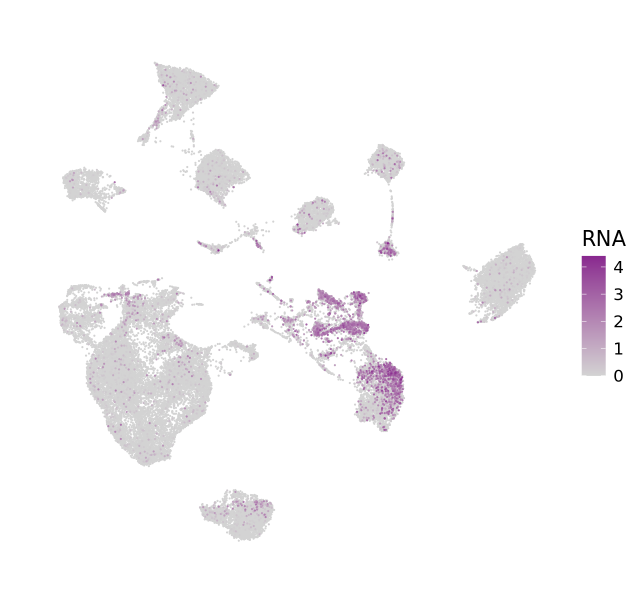

In [21]:
options(repr.plot.width = 6.4, repr.plot.height = 6, repr.plot.res = 100)
ggplot(UMAP, aes(x = umap_1, y = umap_2, color = RNA)) +
  geom_point(size = 0.1) +
  labs(x = "", y = "", title = "") +
  scale_color_gradient(low = "lightgrey", high = "#89288F") +
  theme_minimal() +
  theme(text = element_text(size = 15),
        panel.grid = element_blank(),
        axis.text = element_blank(),
        axis.ticks = element_blank())

In [22]:
UMAP[["RNA"]] <- pmin(pmax(UMAP[["RNA"]], 0), 5)

In [23]:
p1 <- ggplot(UMAP[,c("umap_1","umap_2","RNA")], aes(x = umap_1, y = umap_2, color = `RNA`)) +
    geom_point(size=0.1) +
    labs(x = "", y = "",title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient(low = "lightgrey", high = "#89288F",limits = c(0, 5),breaks = c(0, 5))

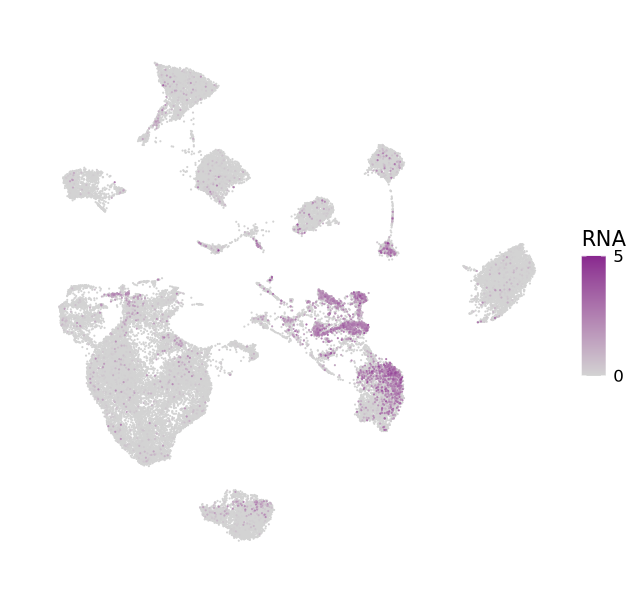

In [24]:
options(repr.plot.width = 6.4, repr.plot.height = 6, repr.plot.res = 100)
p1

In [25]:
aaa <- UMAP

In [26]:
UMAP <- aaa

In [27]:
UMAP[["5hmCG"]] <- pmin(pmax(UMAP[["5hmCG"]], 0.15), 0.35)

In [28]:
p2 <- ggplot(UMAP[,c("umap_1","umap_2","5hmCG")], aes(x = umap_1, y = umap_2, color = `5hmCG`)) +
    geom_point(size=0.1) +
    labs(x = "", y = "",title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient(low = "darkblue", high = "#e6c200",limits = c(0.15, 0.35),breaks = c(0.15, 0.35))

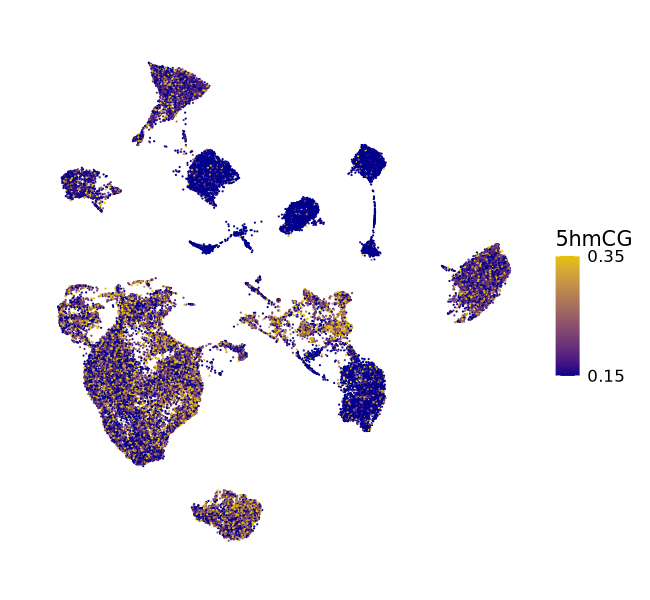

In [29]:
options(repr.plot.width = 6.5, repr.plot.height = 6, repr.plot.res = 100)
p2

In [30]:
UMAP[["5hmCG+5mCG"]] <- pmin(pmax(UMAP[["5hmCG+5mCG"]], 0.3), 1)

In [31]:
p3 <- ggplot(UMAP[,c("umap_1","umap_2","5hmCG+5mCG")], aes(x = umap_1, y = umap_2, color = `5hmCG+5mCG`)) +
    geom_point(size=0.1) +
    labs(x = "", y = "",title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient(low = "darkblue", high = "#e6c200",limits = c(0.3, 1),breaks = c(0.3, 1))

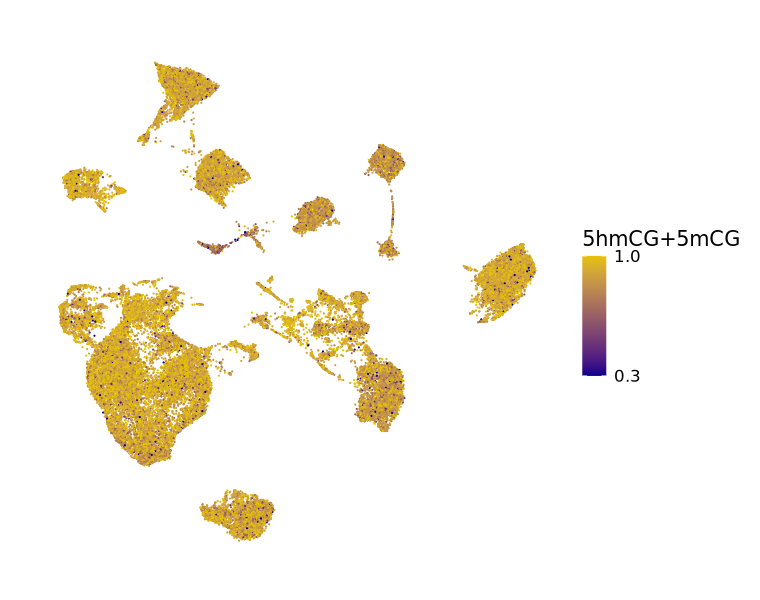

In [32]:
options(repr.plot.width = 7.6, repr.plot.height = 6, repr.plot.res = 100)
p3

In [33]:
UMAP[["5mCG"]] <- pmin(pmax(UMAP[["5mCG"]], 0.3), 1)

In [34]:
p4 <- ggplot(UMAP[,c("umap_1","umap_2","5mCG")], aes(x = umap_1, y = umap_2, color = `5mCG`)) +
    geom_point(size=0.1) +
    labs(x = "", y = "",title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient(low = "darkblue", high = "#e6c200",limits = c(0.3, 1),breaks = c(0.3, 1))

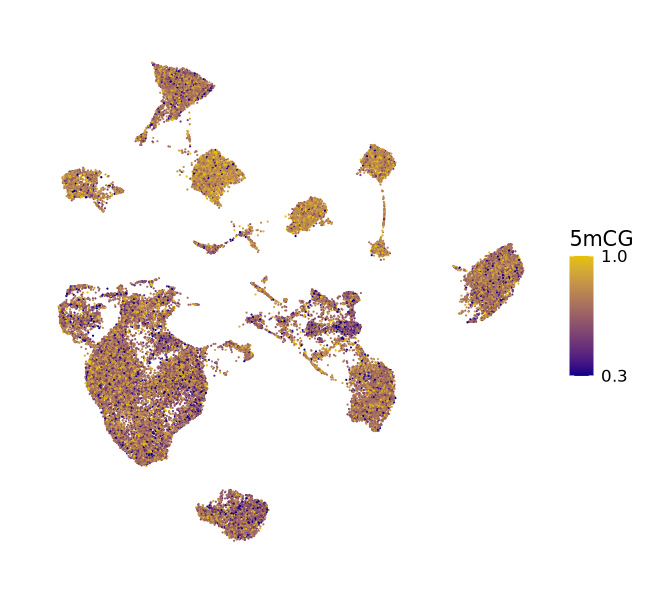

In [35]:
options(repr.plot.width = 6.5, repr.plot.height = 6, repr.plot.res = 100)
p4

In [36]:
UMAP[["5mCG"]] <- pmin(pmax(UMAP[["5mCG"]], 0.3), 0.8)

In [37]:
p5 <- ggplot(UMAP[,c("umap_1","umap_2","5mCG")], aes(x = umap_1, y = umap_2, color = `5mCG`)) +
    geom_point(size=0.1) +
    labs(x = "", y = "",title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient(low = "darkblue", high = "#e6c200",limits = c(0.3, 0.8),breaks = c(0.3, 0.8))

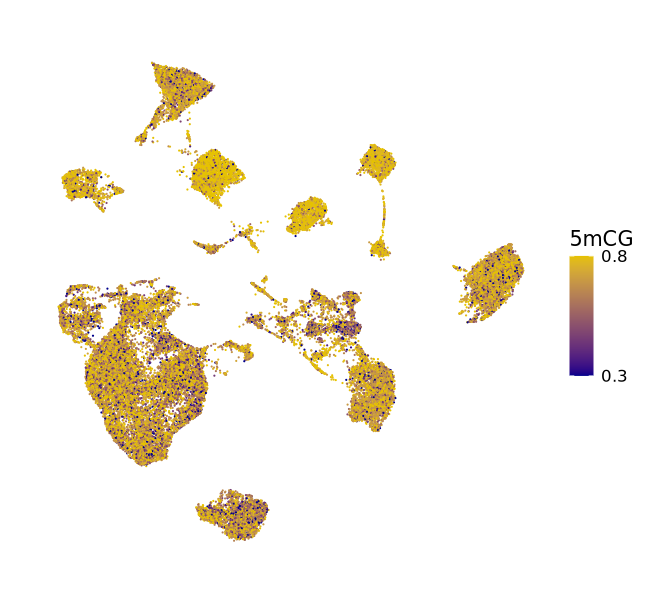

In [38]:
options(repr.plot.width = 6.5, repr.plot.height = 6, repr.plot.res = 100)
p5

In [39]:
library(gridExtra)
library(ggplot2)


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




In [40]:
gpp1 <- arrangeGrob(p1, heights = unit(6, "inches"), widths = unit(6.4, "inches"))
gpp2 <- arrangeGrob(p2, heights = unit(6, "inches"), widths = unit(6.5, "inches"))
gpp3 <- arrangeGrob(p3, heights = unit(6, "inches"), widths = unit(7.6, "inches"))
gpp4 <- arrangeGrob(p4, heights = unit(6, "inches"), widths = unit(6.5, "inches"))

In [41]:
combined_plot <- arrangeGrob(gpp1, gpp2, gpp3, gpp4, ncol = 2, nrow = 2)

In [42]:
ggsave("../output/02-UMAP_show_Vwc2_and_DNA_methylation_ratio_0.3-1.pdf", 
       combined_plot, 
       width = 15, height = 12)

In [43]:
gpp5 <- arrangeGrob(p5, heights = unit(6, "inches"), widths = unit(6.5, "inches"))

In [44]:
combined_plot1 <- arrangeGrob(gpp1, gpp2, gpp3, gpp5, ncol = 2, nrow = 2)

In [45]:
ggsave("../output/02-UMAP_show_Vwc2_and_DNA_methylation_ratio_0.3-0.8.pdf", 
       combined_plot1, 
       width = 15, height = 12)